In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.plotting_fns import PlottingFns
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
from composite import Composite
pfns = PlottingFns()

In [3]:
import gsw
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import root_scalar


In [4]:
sla = SLA(deg=0.25).da
sice = xr.open_dataset('../data/NSIDC/sice_processed.nc')
sice = sice.__xarray_dataarray_variable__
elevation_ = GEBCO(coarsen_factor=40).ds.elevation

In [5]:
def sanom(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()

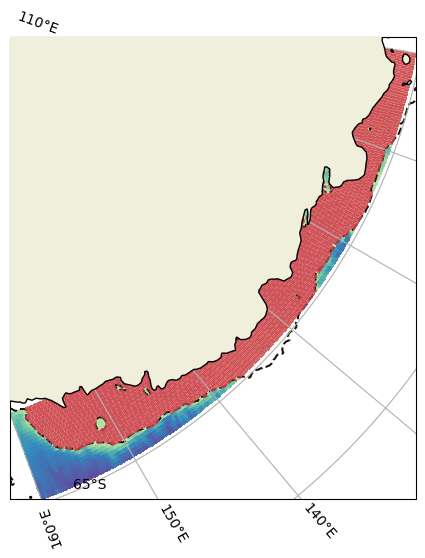

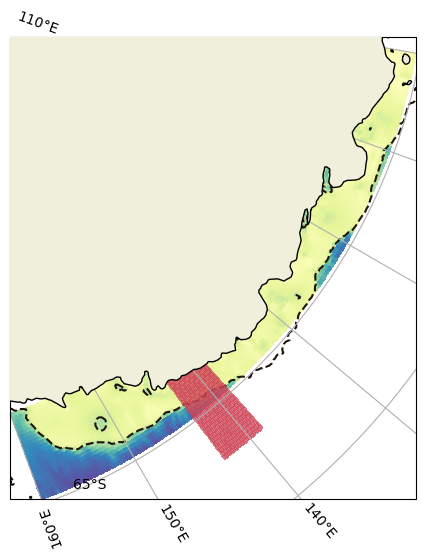

In [6]:
extent =[100,160,-69,-65.2]
extent_mertz =[138.5,143,-67,-63]#-65.6]
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))

shelf = Region('EA Shelf',extent,elevation_,min_elevation=-1000)
mertz = Region('Mertz',extent_mertz)
shelf.plot_region(extent=extent,da=elevation)
mertz.plot_region(extent=extent,da=elevation)

sla_shelf = shelf.crop_da(sla)


In [7]:
# set up lines of constant density

tlims = [-2.1,0.4]
slims = [32.9,34.9]
sig0_n = 100
temprange = np.linspace(tlims[0],tlims[1],sig0_n)
psalrange = np.linspace(slims[0],slims[1],sig0_n)

sig0range = np.zeros((sig0_n,sig0_n))
for i,t in enumerate(temprange):
    for j,s in enumerate(psalrange):
        sig0range[i,j]=gsw.sigma0(s,gsw.CT_from_t(s,t,0))


In [8]:
meop_mertz=MEOP(extent=extent_mertz)

In [9]:
meop_mertz.load_profiles_for_spira()

  0%|          | 0/82 [00:00<?, ?it/s]

100%|██████████| 82/82 [02:14<00:00,  1.64s/it]


In [10]:
meop_mertz.ds['elevation'] = elevation.interp(latitude=meop_mertz.ds.lat,longitude=meop_mertz.ds.lon).drop(['longitude','latitude'])
meop_mertz.ds['month'] = meop_mertz.ds.time.dt.month

In [11]:
def get_seasons(dspira_mertz):
    seasons={}
    seasons['autumn']=dspira_mertz.where(((dspira_mertz.month >= 4) & (dspira_mertz.month <= 6)),drop=True)
    seasons['winter']=dspira_mertz.where(((dspira_mertz.month >= 7) & (dspira_mertz.month <= 9)),drop=True)
    seasons['spring']=dspira_mertz.where(((dspira_mertz.month >= 10) & (dspira_mertz.month <= 12)),drop=True)
    seasons['summer']=dspira_mertz.where(((dspira_mertz.month >= 1) & (dspira_mertz.month <= 3)),drop=True)
    return seasons


In [18]:
ds_shelf = meop_mertz.ds.where(meop_mertz.ds.elevation > -1000,drop=True)
#ds_excsum = ds_shelf.where(ds_shelf.month > 3,drop=True)
seasons=get_seasons(ds_shelf)

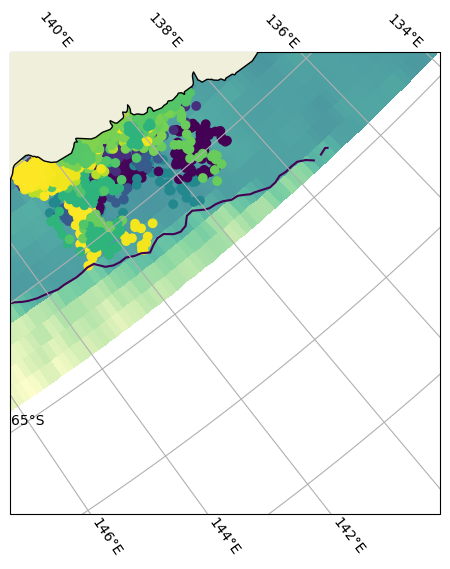

In [13]:
fig,ax=plt.subplots(figsize=(8,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent_mertz,cmap=cmocean.cm.deep,land_zorder=3)
im=ax.scatter(ds_excsum.lon,ds_excsum.lat,c=ds_excsum.time,transform=ccrs.PlateCarree())
ax.contour(elevation.longitude,elevation.latitude, elevation,levels=[-1000],transform=ccrs.PlateCarree())

In [19]:
background_data = sanom(mertz.crop_da(sla)).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

cmp = Composite(idx_data,'SLA')
#cmp.add_meop(meop_mertz,tlims=tlims,slims=slims)
cmp.add_spira(seasons['autumn'],tlims=tlims,slims=slims)

In [20]:
cmp.build_sns_data()

preparing data


In [16]:
cmp.sns_data

,time,temperature,salinity,pressure,sigma0,SLA,month,year
0,2007-04-01 21:49:58,NaN,NaN,0,NaN,+ SLA,4,2007
1,2007-04-02 03:00:00,NaN,NaN,0,NaN,+ SLA,4,2007
2,2007-04-02 09:10:00,NaN,NaN,0,NaN,+ SLA,4,2007
3,2007-04-02 15:00:00,-1.858903,34.197128,0,27.401983,+ SLA,4,2007
4,2007-04-03 15:00:00,-1.858593,34.197235,0,27.402061,+ SLA,4,2007
...,...,...,...,...,...,...,...,...
1609495,2019-06-08 07:49:59,NaN,NaN,-998,NaN,- SLA,6,2019
1609496,2019-06-08 23:09:59,NaN,NaN,-998,NaN,- SLA,6,2019
1609497,2019-06-09 15:50:00,NaN,NaN,-998,NaN,- SLA,6,2019
1609498,2019-06-11 00:10:00,NaN,NaN,-998,NaN,- SLA,6,2019


preparing lag=6 months
preparing data
plotting..


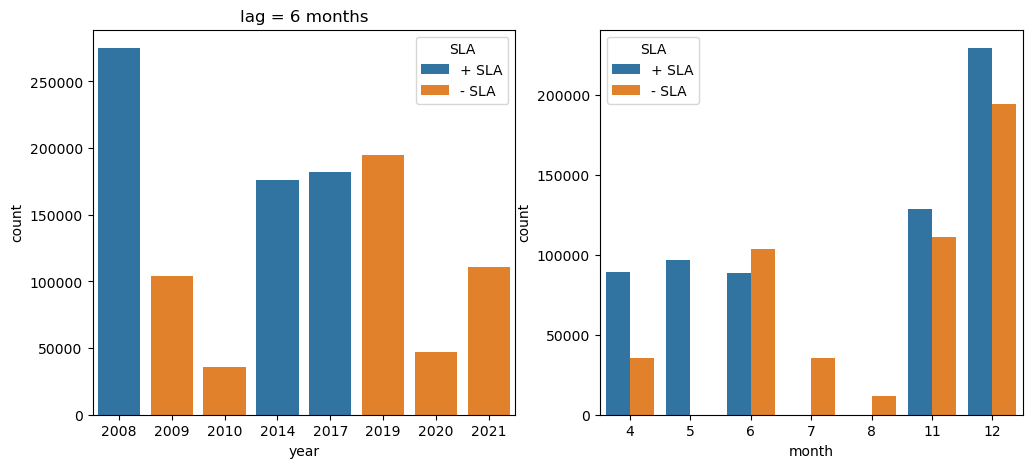

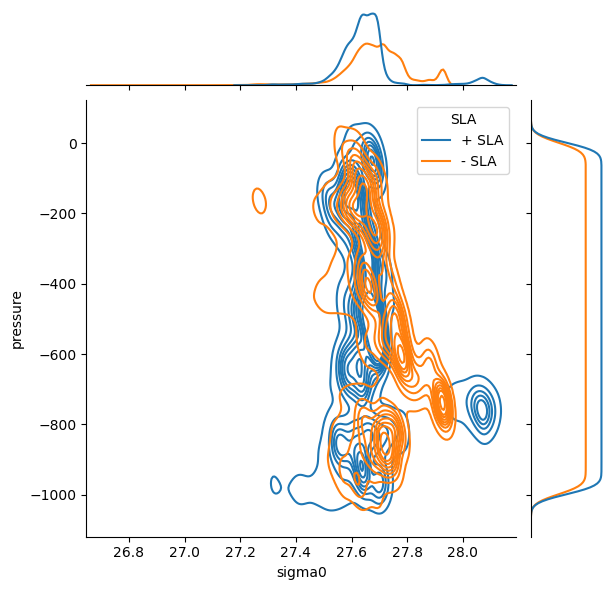

In [21]:
background_data = sanom(mertz.crop_da(sla)).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

#for l in np.arange(12):
l=6
print('preparing lag={} months'.format(l))
cmp = Composite(idx_data,'SLA')
cmp.add_spira(ds_excsum,tlims=tlims,slims=slims,lag=l)
cmp.build_sns_data()

fig, ax = plt.subplots(1,2,figsize=(12,5))
sns.countplot(cmp.sns_data, x='year', hue='SLA',ax=ax[0])
sns.countplot(cmp.sns_data, x='month', hue='SLA',ax=ax[1])
ax[0].set_title('lag = {} months'.format(l))

print('plotting..')
g = sns.JointGrid(data=cmp.sns_data, x='sigma0', y ='pressure', hue='SLA')
g.plot(sns.kdeplot, sns.kdeplot)

In [ ]:
sns.kdeplot(data=cmp.sns_data,x='sigma0',y='pressure', hue='SLA')

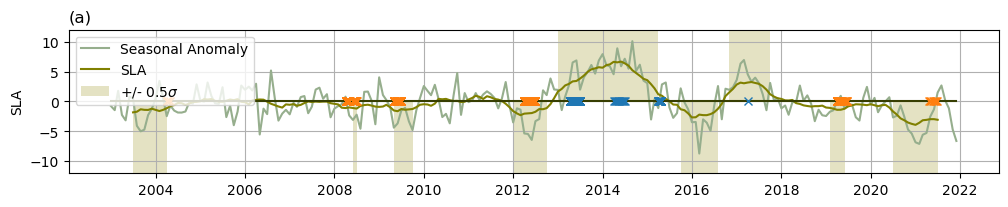

In [17]:
fig = plt.figure(figsize=(12,22))
gs = fig.add_gridspec(10,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])

cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly')

In [107]:
def get_pressure_band(p):
    if p > -50:
        return '0-50dbar'
    elif p > -100:
        return '50-100dbar'
    elif p > -200:
        return '100-200dbar'
    elif p > -300:
        return '200-300dbar'
cmp.sns_data['pressure_band']=[get_pressure_band(p) for p in cmp.sns_data.pressure]

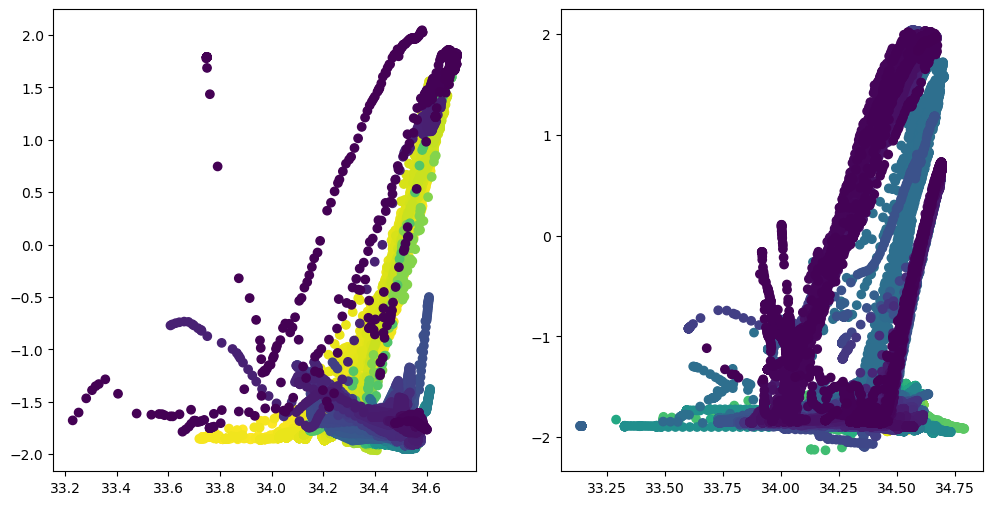

In [112]:
fig = plt.figure(figsize=(12,6))
gs = fig.add_gridspec(1,2)

pos = cmp.sns_data[cmp.sns_data.SLA=='+ SLA']
neg = cmp.sns_data[cmp.sns_data.SLA=='- SLA']
fig.add_subplot(gs[0, 0]).scatter(pos.salinity,pos.temperature,c=pos.pressure,vmin=-300,vmax=0)
fig.add_subplot(gs[0, 1]).scatter(neg.salinity,neg.temperature,c=neg.pressure,vmin=-300,vmax=0)


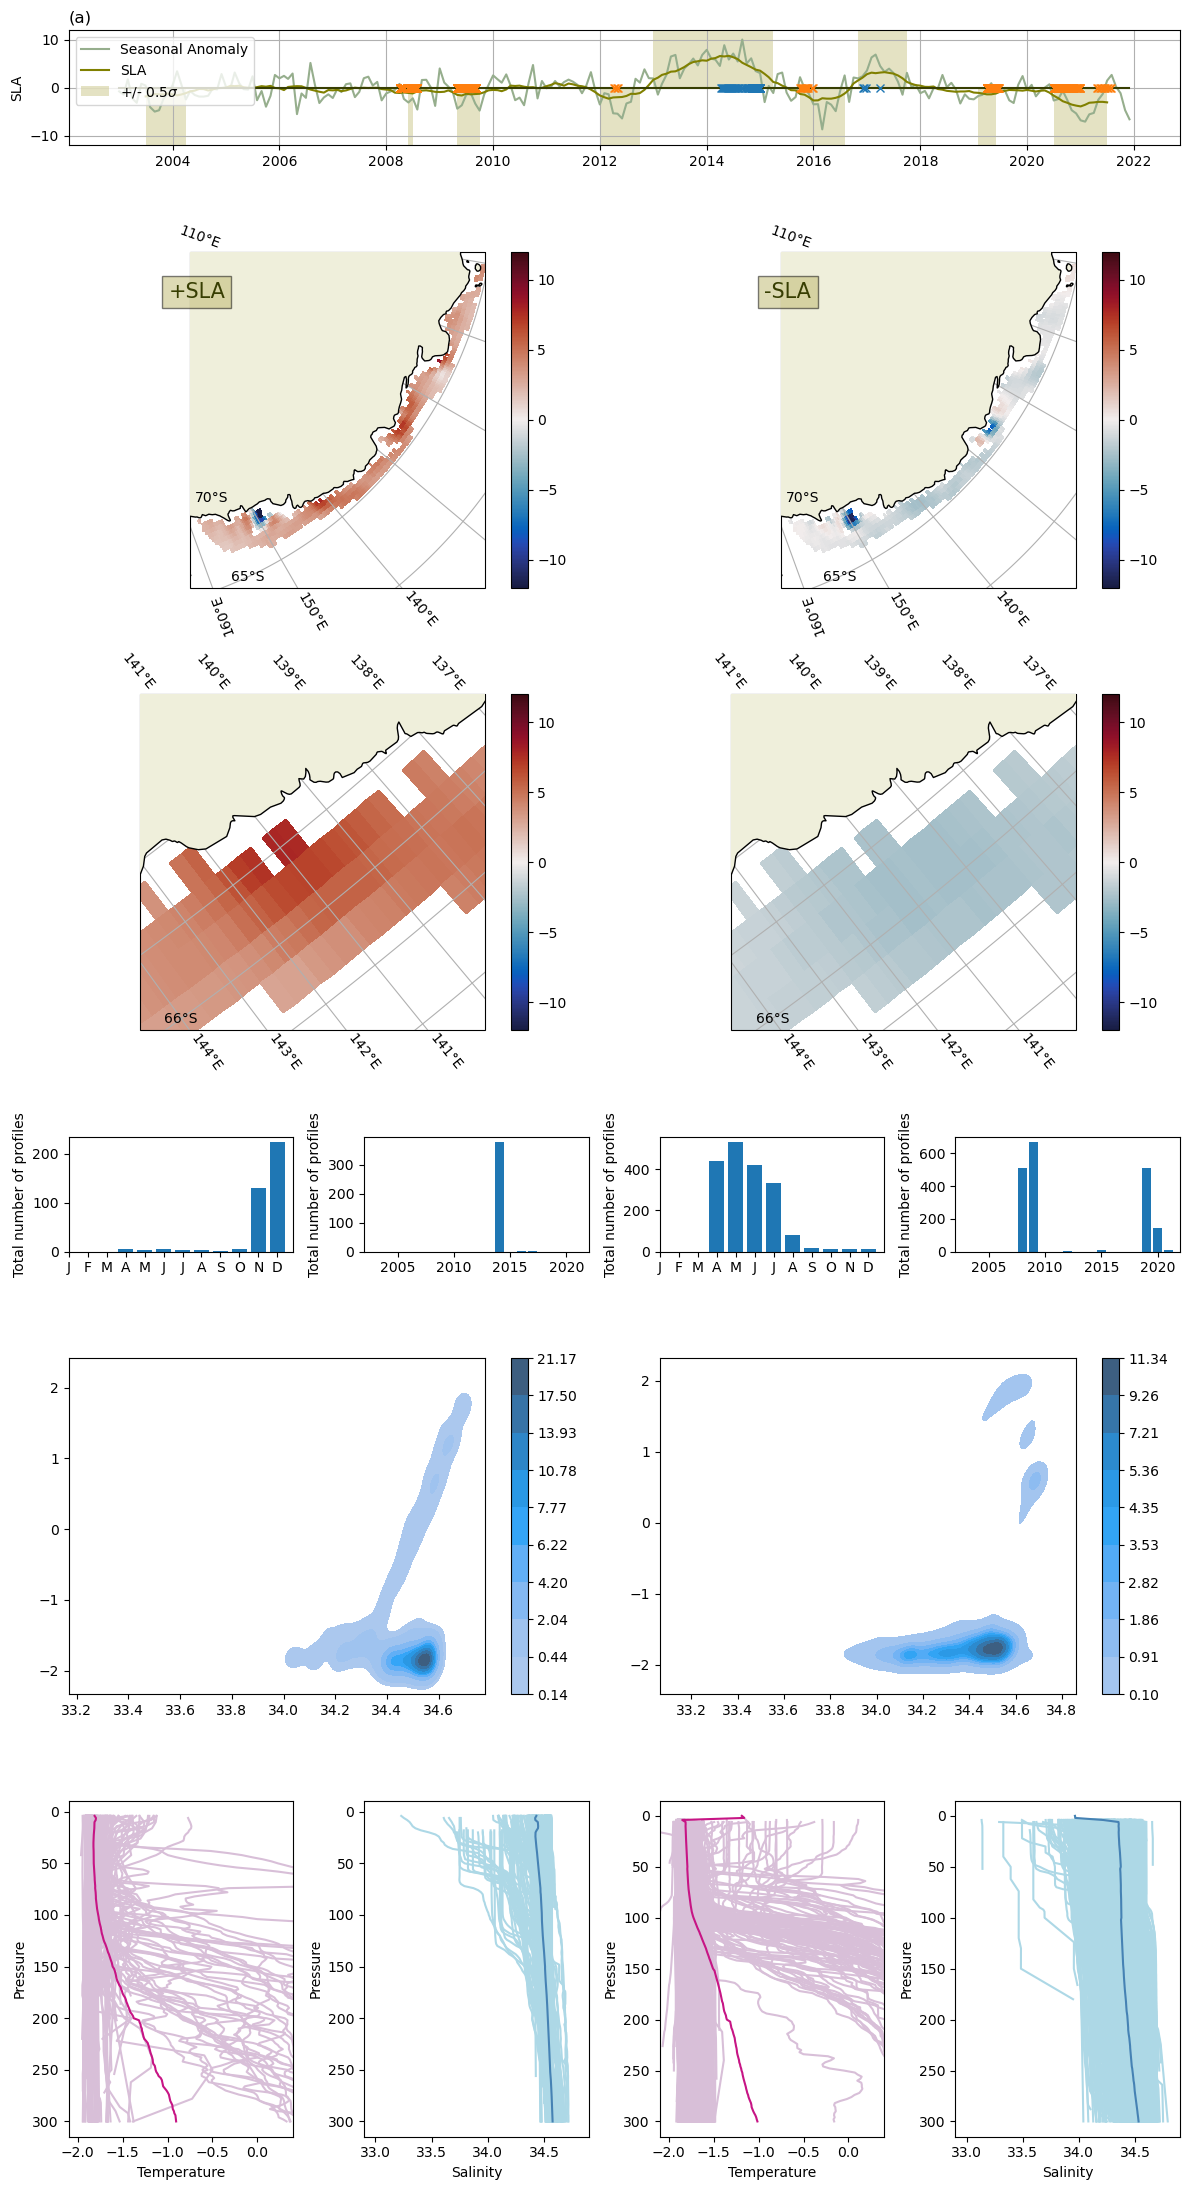

In [ ]:
fig = plt.figure(figsize=(12,22))
gs = fig.add_gridspec(10,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])

cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly')
# FIG2: SLA MAP
ax2 = fig.add_subplot(gs[1:3, 0:2],projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(gs[1:3, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax2,ax3],sanom(shelf.crop_da(sla)),'SLA',12,extent,label_loc=[130,-80])

# FIG3: SLA closeup
ax4 = fig.add_subplot(gs[3:5, 0:2],projection=ccrs.SouthPolarStereo())
ax5 = fig.add_subplot(gs[3:5, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax4,ax5],sanom(shelf.crop_da(sla)),'SLA',12,extent_mertz,add_profiles=True)

n = 5
cmp.ts_freq_plot([ 
    fig.add_subplot(gs[n,0]),
    fig.add_subplot(gs[n,1]),
    fig.add_subplot(gs[n,2]),
    fig.add_subplot(gs[n,3]),
])

# FIG4: TS DESNITY
n = 6
# cmp.ts_density([
    # fig.add_subplot(gs[n:n+2,0:2]),
    # fig.add_subplot(gs[n:n+2,2:4])
    # ])

ax6 = fig.add_subplot(gs[n:n+2,0:2])
ax7 = fig.add_subplot(gs[n:n+2,2:4])

sns.kdeplot(ax=ax6, data=cmp.sns_data ,x=cmp.s_pos.values.flatten(), y=cmp.t_pos.values.flatten(), hue=cmp., cbar=True)
sns.kdeplot(ax=ax7, data=cmp.snsx=cmp.s_neg.values.flatten(), y=cmp.t_neg.values.flatten(),fill=True, cbar=True)

# FIG5: TS PROFILES
n = 8
ax8 = fig.add_subplot(gs[8:10,0])
ax9 = fig.add_subplot(gs[8:10,1])
ax10 = fig.add_subplot(gs[8:10,2])
ax11 = fig.add_subplot(gs[8:10,3])
cmp.ts_profiles([ax8,ax9,ax10,ax11])

plt.tight_layout()



In [16]:
background_data = sanom(sla_shelf).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

cmp = Composite(idx_data,'SLA')
cmp.add_meop(meop_mertz,tlims=tlims,slims=slims,lag=6)

reindexing temps..
reindexing psals...
merging...
reindexing temps..
reindexing psals...
merging...


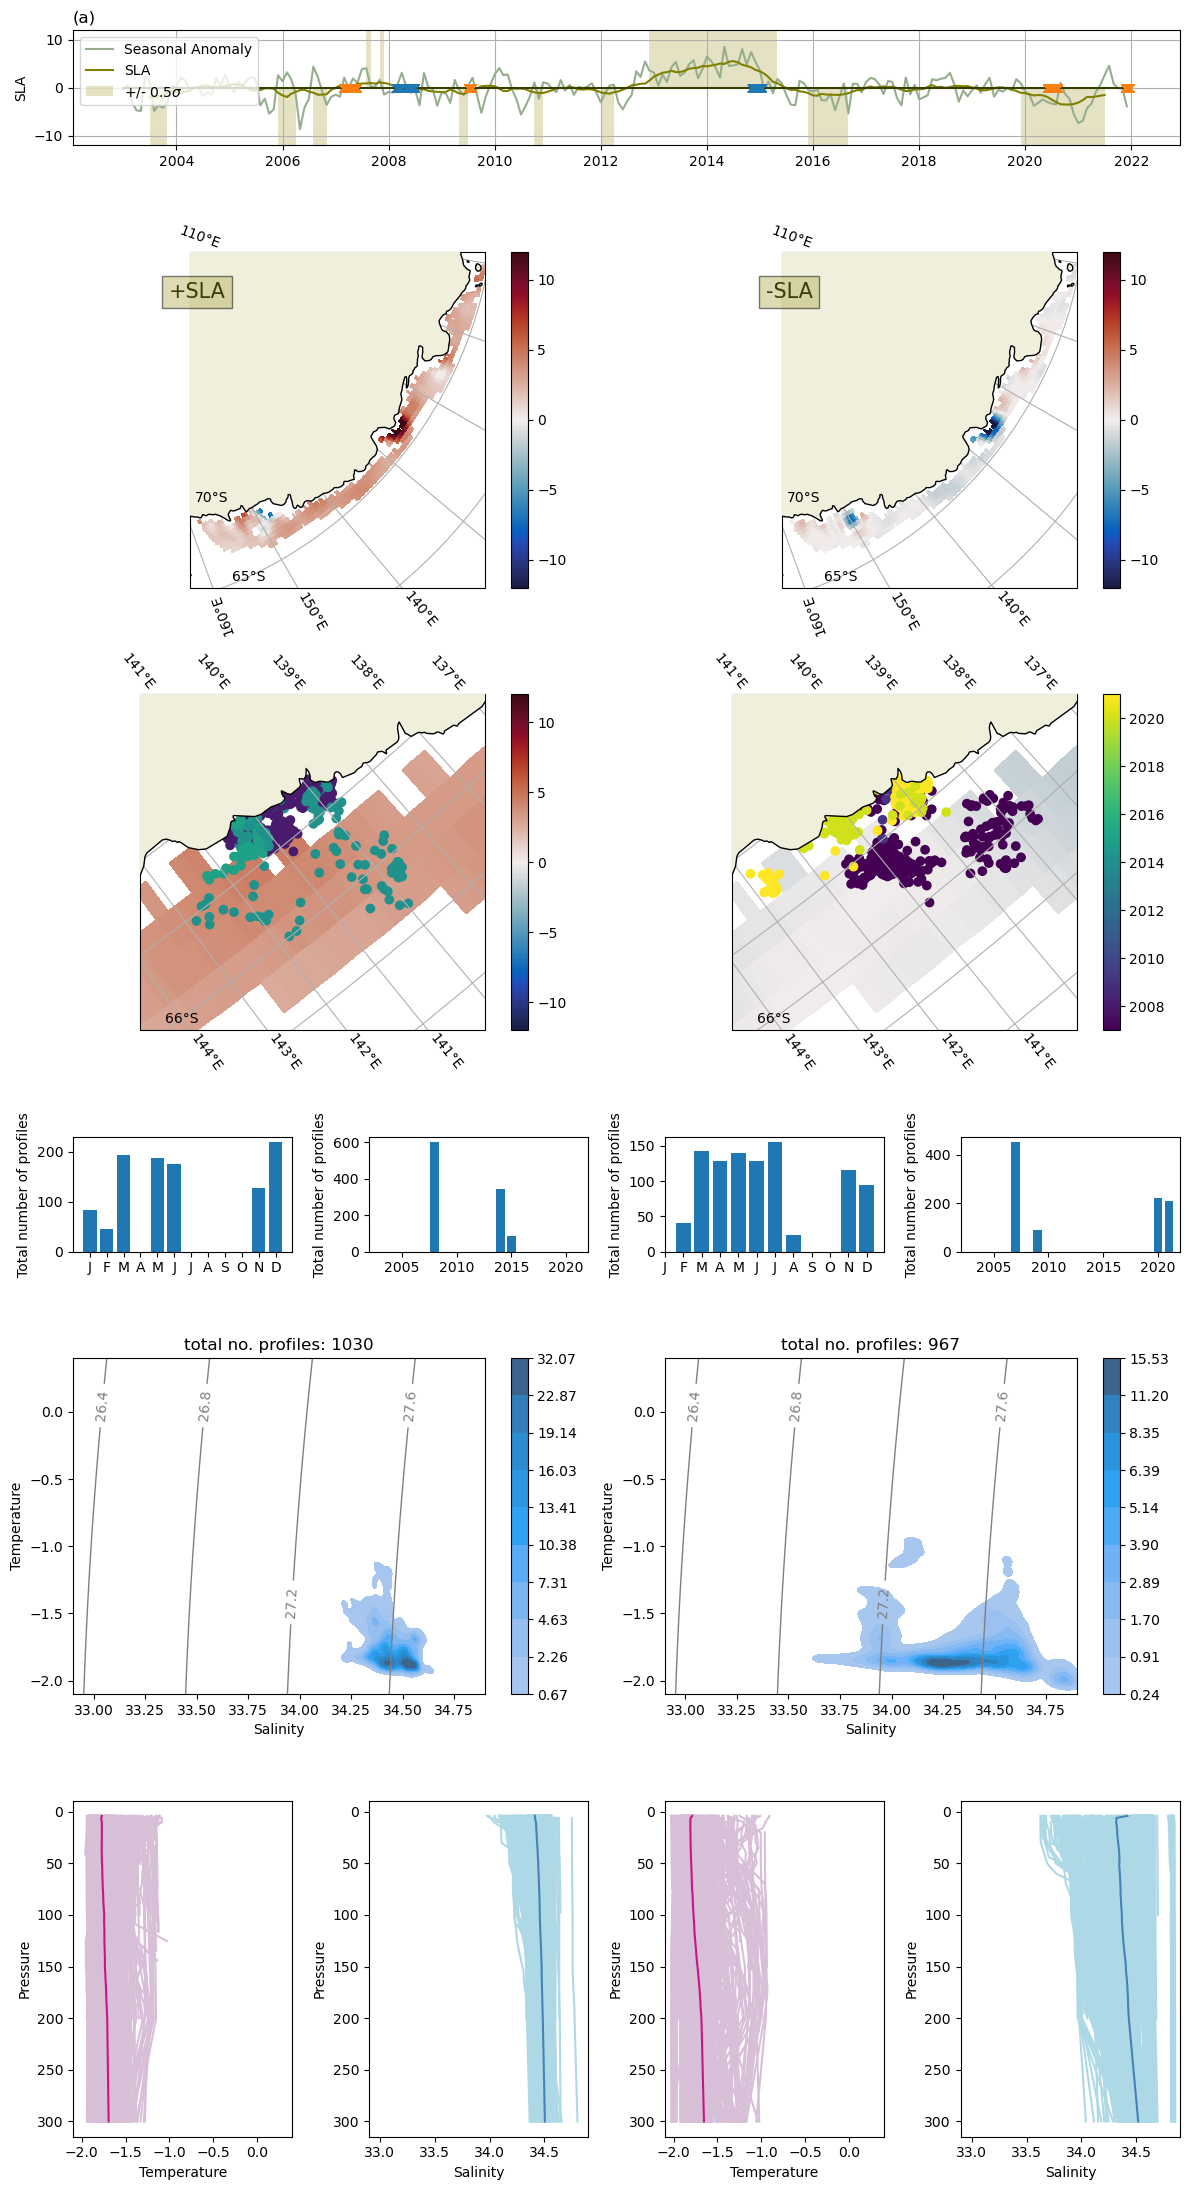

In [17]:
fig = plt.figure(figsize=(12,22))
gs = fig.add_gridspec(10,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])

cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly')
# FIG2: SLA MAP
ax2 = fig.add_subplot(gs[1:3, 0:2],projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(gs[1:3, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax2,ax3],sanom(shelf.crop_da(sla)),'SLA',12,extent,label_loc=[130,-80])

# FIG3: SLA closeup
ax4 = fig.add_subplot(gs[3:5, 0:2],projection=ccrs.SouthPolarStereo())
ax5 = fig.add_subplot(gs[3:5, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax4,ax5],sanom(shelf.crop_da(sla)),'SLA',12,extent_mertz,add_profiles=True)

n = 5
cmp.ts_freq_plot([ 
    fig.add_subplot(gs[n,0]),
    fig.add_subplot(gs[n,1]),
    fig.add_subplot(gs[n,2]),
    fig.add_subplot(gs[n,3]),
])

# FIG4: TS DESNITY
n = 6
cmp.ts_density([
    fig.add_subplot(gs[n:n+2,0:2]),
    fig.add_subplot(gs[n:n+2,2:4])
    ])

# FIG5: TS PROFILES
n = 8
ax8 = fig.add_subplot(gs[8:10,0])
ax9 = fig.add_subplot(gs[8:10,1])
ax10 = fig.add_subplot(gs[8:10,2])
ax11 = fig.add_subplot(gs[8:10,3])
cmp.ts_profiles([ax8,ax9,ax10,ax11])

plt.tight_layout()



In [18]:
tm_pos,p_pos = np.meshgrid(cmp.t_pos.time,cmp.t_pos.pressure)
tm_neg,p_neg = np.meshgrid(cmp.t_neg.time,cmp.t_neg.pressure)
p_pos = p_pos.flatten()
p_neg=p_neg.flatten()
tm_pos = tm_pos.flatten()
tm_neg = tm_neg.flatten()
rho_pos = gsw.density.sigma0(cmp.s_pos.values,cmp.t_pos.values).flatten()
rho_neg = gsw.density.sigma0(cmp.s_neg.values,cmp.t_neg.values).flatten()

In [22]:
sns_data = pd.DataFrame(data={'time':np.concatenate([tm_pos,tm_neg]),
                              'temperature':np.concatenate([cmp.t_pos.values.flatten(),cmp.t_neg.values.flatten()]),
                              'salinity':np.concatenate([cmp.s_pos.values.flatten(),cmp.s_neg.values.flatten()]),
                              'pressure':-np.concatenate([p_pos,p_neg]),
                              'potential density': np.concatenate([rho_pos,rho_neg]),
                              'SLA': ['+ SLA' for _ in tm_pos] + ['- SLA' for _ in tm_neg],
                              'month': get_month(np.concatenate([tm_pos,tm_neg])),
                              'year': pd.to_datetime(np.concatenate([tm_pos,tm_neg])).year
                              })

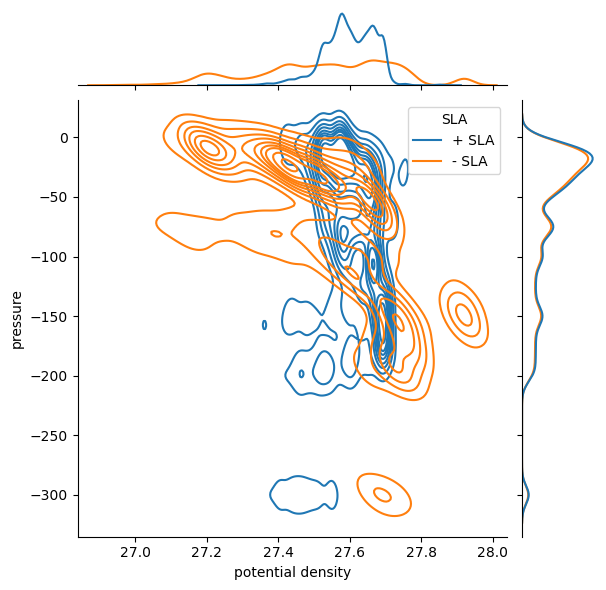

In [23]:
g = sns.JointGrid(data=sns_data, x='potential density', y ='pressure', hue='SLA')
g.plot(sns.kdeplot, sns.kdeplot)

In [24]:
background_data = sanom(sla_shelf).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

cmp = Composite(idx_data,'SLA')
cmp.add_meop(meop_mertz,tlims=tlims,slims=slims,lag=2)

reindexing temps..
reindexing psals...
merging...
reindexing temps..
reindexing psals...
merging...


In [26]:
tm_pos,p_pos = np.meshgrid(cmp.t_pos.time,cmp.t_pos.pressure)
tm_neg,p_neg = np.meshgrid(cmp.t_neg.time,cmp.t_neg.pressure)
p_pos = p_pos.flatten()
p_neg=p_neg.flatten()
tm_pos = tm_pos.flatten()
tm_neg = tm_neg.flatten()
rho_pos = gsw.density.sigma0(cmp.s_pos.values,cmp.t_pos.values).flatten()
rho_neg = gsw.density.sigma0(cmp.s_neg.values,cmp.t_neg.values).flatten()
ssn_pos = [get_season(t) for t in tm_pos]
ssn_neg = [get_season(t) for t in tm_neg]

In [27]:
sns_data = pd.DataFrame(data={'time':np.concatenate([tm_pos,tm_neg]),
                              'temperature':np.concatenate([cmp.t_pos.values.flatten(),cmp.t_neg.values.flatten()]),
                              'salinity':np.concatenate([cmp.s_pos.values.flatten(),cmp.s_neg.values.flatten()]),
                              'pressure':-np.concatenate([p_pos,p_neg]),
                              'potential density': np.concatenate([rho_pos,rho_neg]),
                              'SLA': ['+ SLA' for _ in tm_pos] + ['- SLA' for _ in tm_neg],
                              'month': get_month(np.concatenate([tm_pos,tm_neg])),
                              'year': pd.to_datetime(np.concatenate([tm_pos,tm_neg])).year
                              })

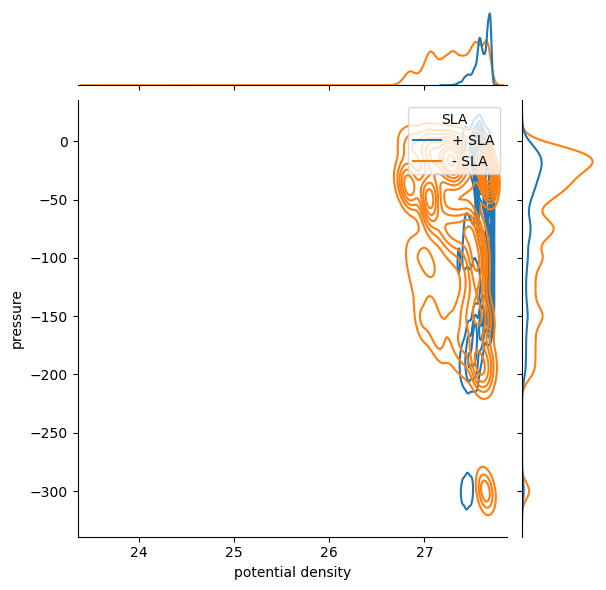

In [28]:
g = sns.JointGrid(data=sns_data, x='potential density', y ='pressure', hue='SLA')
g.plot(sns.kdeplot, sns.kdeplot)

In [29]:
background_data = sanom(sla_shelf).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

cmp = Composite(idx_data,'SLA')
cmp.add_meop(meop_mertz,tlims=tlims,slims=slims,lag=3)
tm_pos,p_pos = np.meshgrid(cmp.t_pos.time,cmp.t_pos.pressure)
tm_neg,p_neg = np.meshgrid(cmp.t_neg.time,cmp.t_neg.pressure)
p_pos = p_pos.flatten()
p_neg=p_neg.flatten()
tm_pos = tm_pos.flatten()
tm_neg = tm_neg.flatten()
rho_pos = gsw.density.sigma0(cmp.s_pos.values,cmp.t_pos.values).flatten()
rho_neg = gsw.density.sigma0(cmp.s_neg.values,cmp.t_neg.values).flatten()
ssn_pos = [get_season(t) for t in tm_pos]
ssn_neg = [get_season(t) for t in tm_neg]
sns_data = pd.DataFrame(data={'time':np.concatenate([tm_pos,tm_neg]),
                              'temperature':np.concatenate([cmp.t_pos.values.flatten(),cmp.t_neg.values.flatten()]),
                              'salinity':np.concatenate([cmp.s_pos.values.flatten(),cmp.s_neg.values.flatten()]),
                              'pressure':-np.concatenate([p_pos,p_neg]),
                              'potential density': np.concatenate([rho_pos,rho_neg]),
                              'SLA': ['+ SLA' for _ in tm_pos] + ['- SLA' for _ in tm_neg],
                              'month': get_month(np.concatenate([tm_pos,tm_neg])),
                              'year': pd.to_datetime(np.concatenate([tm_pos,tm_neg])).year
                              })

reindexing temps..
reindexing psals...
merging...
reindexing temps..
reindexing psals...
merging...


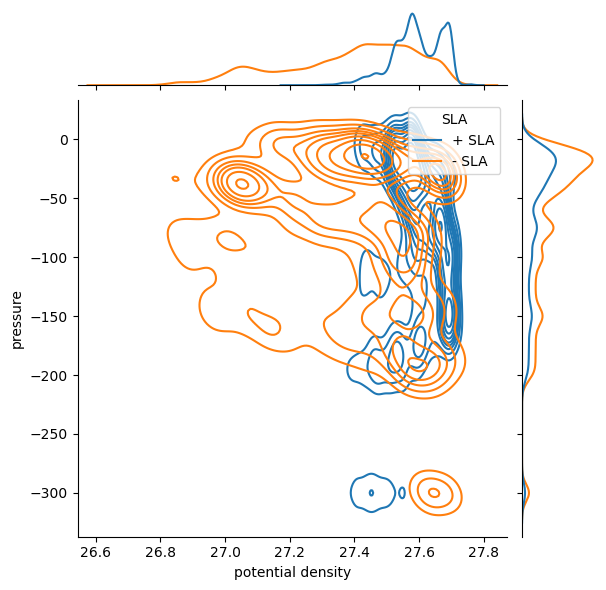

In [30]:
g = sns.JointGrid(data=sns_data, x='potential density', y ='pressure', hue='SLA')
g.plot(sns.kdeplot, sns.kdeplot)